# Retention Ranking Analysis

Checkpoint 43 evaluates how effectively the selected sigmoid-calibrated Logistic Regression prioritizes validation-period attrition cases. The 2025 test target remains locked.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED = PROJECT_ROOT / 'data' / 'processed'

ranking = pd.read_csv(PROCESSED / 'retention_ranking_metrics.csv')
summary = pd.read_csv(PROCESSED / 'retention_ranking_summary.csv')
curves = pd.read_csv(PROCESSED / 'retention_curve_points.csv')
confusion = pd.read_csv(PROCESSED / 'retention_top_decile_confusion_matrix.csv')
validation = pd.read_csv(PROCESSED / 'retention_ranking_validation.csv')

print(f'Ranking grid rows: {len(ranking):,}')
print(f"Checks passed: {(validation['status'] == 'PASS').sum()}/{len(validation)}")
summary.round(4)

Ranking grid rows: 12
Checks passed: 19/19


,selected_calibration_method,snapshot_date,validation_rows,positive_cases,positive_rate,pr_auc,pr_auc_lift_over_no_skill,roc_auc,reporting_fraction,reporting_selected_count,reporting_precision,reporting_capture_rate,reporting_lift,reporting_probability_cutoff,true_negative,false_positive,false_negative,true_positive,final_operating_threshold_selected
0,Sigmoid,2024-06-30,5521,586,0.1061,0.1638,1.5434,0.6211,0.1,553,0.1971,0.186,1.857,0.1452,4491,444,477,109,False


## Top-k metrics

Precision measures concentration inside the selected group. Capture measures the share of all attrition cases found. Lift compares the selected group with random selection.

In [2]:
ranking[[
    'requested_fraction',
    'selected_count',
    'captured_positive_cases',
    'precision_at_k',
    'capture_rate_at_k',
    'lift_at_k',
    'precision_at_k_lower_95',
    'precision_at_k_upper_95',
]].round(4)

,requested_fraction,selected_count,captured_positive_cases,precision_at_k,capture_rate_at_k,lift_at_k,precision_at_k_lower_95,precision_at_k_upper_95
0,0.010,56,14,0.2500,0.0239,2.3554,0.1429,0.3929
1,0.025,139,34,0.2446,0.0580,2.3045,0.1799,0.3237
2,0.050,277,58,0.2094,0.0990,1.9727,0.1678,0.2618
3,0.100,553,109,0.1971,0.1860,1.8570,0.1672,0.2297
4,0.150,829,144,0.1737,0.2457,1.6365,0.1526,0.1973
5,0.200,1105,190,0.1719,0.3242,1.6200,0.1534,0.1910
6,0.250,1381,227,0.1644,0.3874,1.5486,0.1484,0.1781
7,0.300,1657,259,0.1563,0.4420,1.4726,0.1415,0.1696
8,0.400,2209,324,0.1467,0.5529,1.3819,0.1344,0.1566
9,0.500,2761,383,0.1387,0.6536,1.3069,0.1304,0.1472


## Precision-recall curve

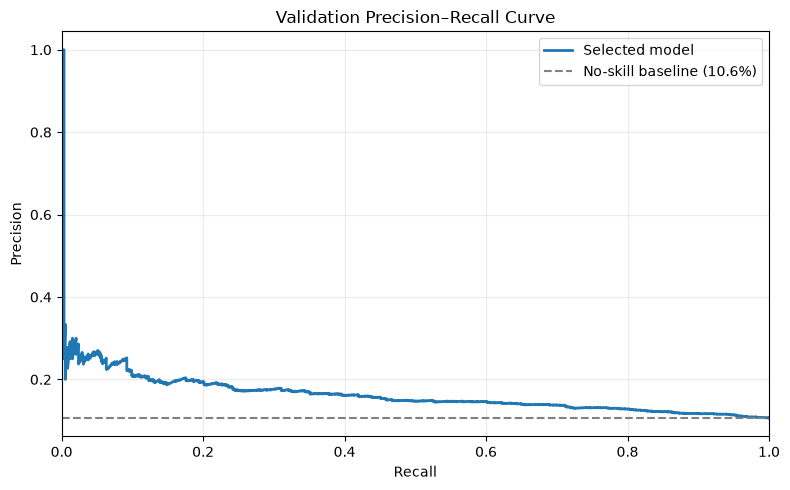

In [3]:
pr = curves.loc[curves['curve_type'].eq('precision_recall')]
baseline = float(summary.loc[0, 'positive_rate'])
figure, axis = plt.subplots(figsize=(8, 5))
axis.plot(pr['x'], pr['y'], linewidth=2, label='Selected model')
axis.axhline(baseline, linestyle='--', color='gray', label=f'No-skill baseline ({baseline:.1%})')
axis.set(xlabel='Recall', ylabel='Precision', title='Validation Precision–Recall Curve', xlim=(0, 1))
axis.legend()
axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Cumulative gains

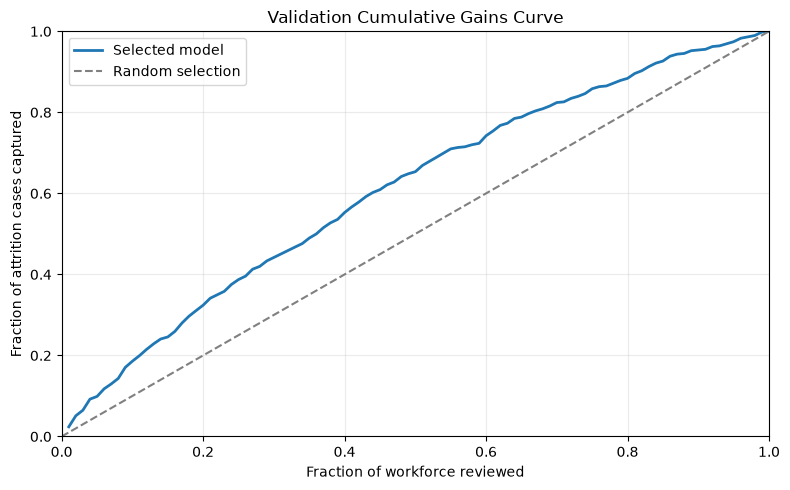

In [4]:
gains = curves.loc[curves['curve_type'].eq('cumulative_gains')]
figure, axis = plt.subplots(figsize=(8, 5))
axis.plot(gains['x'], gains['y'], linewidth=2, label='Selected model')
axis.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random selection')
axis.set(
    xlabel='Fraction of workforce reviewed',
    ylabel='Fraction of attrition cases captured',
    title='Validation Cumulative Gains Curve',
    xlim=(0, 1),
    ylim=(0, 1),
)
axis.legend()
axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Lift curve

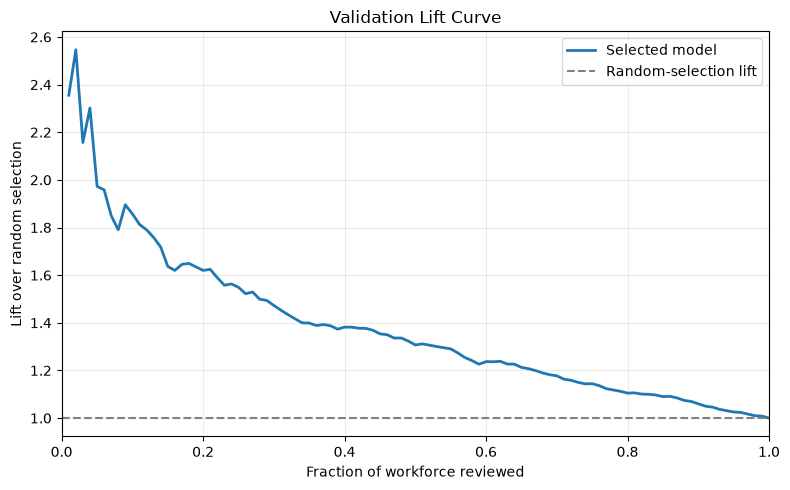

In [5]:
lift = curves.loc[curves['curve_type'].eq('lift')]
figure, axis = plt.subplots(figsize=(8, 5))
axis.plot(lift['x'], lift['y'], linewidth=2, label='Selected model')
axis.axhline(1, linestyle='--', color='gray', label='Random-selection lift')
axis.set(
    xlabel='Fraction of workforce reviewed',
    ylabel='Lift over random selection',
    title='Validation Lift Curve',
    xlim=(0, 1),
)
axis.legend()
axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Top-decile reporting matrix

This matrix describes the highest-ranked 10%. It does not choose the final business threshold.

In [6]:
confusion.pivot(
    index='actual_outcome',
    columns='selection_outcome',
    values='count',
)

selection_outcome,Not selected,Selected top 10%
actual_outcome,,
Attrition,477,109
No attrition,4491,444


The model provides moderate prioritization value: the highest-ranked 10% contains 18.6% of validation attrition cases and has 1.86 times the population attrition concentration. The overlapping score distributions and 0.621 ROC-AUC show that the model is not certain about individual outcomes.